# 아파트 가격 영향 변수 Top 5 분석 

## 1. 라이브러리 임포트

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor


## 2. 데이터 로드 및 타깃 생성

In [6]:
# 선형회귀 / 라쏘 / 릿지용 데이터
df = pd.read_csv(r'C:\3_1_DataMining\NewCity-Apartment-Price-Prediction\data\new_city.csv', encoding='utf-8-sig')

df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)
df['m2당가격'] = df['거래금액(만원)'] / df['전용면적(㎡)']

print('데이터 크기(new_city):', df.shape)
print('계약연도 범위:', df['계약연도'].min(), '~', df['계약연도'].max())
print('도시명:', df['도시명'].unique())


# KNN / RandomForest용 데이터
df_geo = pd.read_csv(r'C:\3_1_DataMining\NewCity-Apartment-Price-Prediction\data\real_new_city.csv', encoding='utf-8-sig')

df_geo['거래금액(만원)'] = df_geo['거래금액(만원)'].str.replace(',', '').astype(int)
df_geo['m2당가격'] = df_geo['거래금액(만원)'] / df_geo['전용면적(㎡)']

print('\n데이터 크기(new_city_within_geomdan):', df_geo.shape)
print('계약연도 범위:', df_geo['계약연도'].min(), '~', df_geo['계약연도'].max())
print('도시명:', df_geo['도시명'].unique())


데이터 크기(new_city): (90761, 35)
계약연도 범위: 2006 ~ 2026
도시명: <StringArray>
['청라', '송도', '판교', '광교', '운정']
Length: 5, dtype: str

데이터 크기(new_city_within_geomdan): (126375, 29)
계약연도 범위: 2006 ~ 2026
도시명: <StringArray>
['청라', '송도', '판교', '광교', '운정', '검단']
Length: 6, dtype: str


## 3. 피처 선택 및 이상치 제거

In [7]:
features = [
    '건축년도',
    '층',
    '지하철호선개수',
    '기차역까지의거리',
    '가장 가까운 지하철역까지의 거리',
    '가장 가까운 IC와의 거리',
    '발표후경과년수',
    'CPI',
    '계약연도',
    '서울도심거리',
    '단지별_세대수',
    '도시별_세대수',
]

# ── new_city.csv 전처리 (선형회귀 / 라쏘 / 릿지용) ──
df = df[df['전용면적(㎡)'] >= 33]

before = len(df)
df = df[df['발표후경과년수'] >= 3]
print(f"[new_city] 발표후경과년수 3 미만 제거: {before - len(df)}개 → 남은 데이터: {len(df)}개")

mean = df['m2당가격'].mean()
std  = df['m2당가격'].std()
df   = df[(((df['m2당가격'] - mean) / std).abs() <= 2)]
df   = df.dropna(subset=features + ['m2당가격'])
print(f'[new_city] 사용 데이터: {len(df)}행  /  피처: {len(features)}개')


# ── new_city_within_geomdan.csv 전처리 (KNN / RandomForest용) ──
df_geo = df_geo[df_geo['전용면적(㎡)'] >= 33]

before_geo = len(df_geo)
df_geo = df_geo[df_geo['발표후경과년수'] >= 3]
print(f"\n[geomdan] 발표후경과년수 3 미만 제거: {before_geo - len(df_geo)}개 → 남은 데이터: {len(df_geo)}개")

mean_geo = df_geo['m2당가격'].mean()
std_geo  = df_geo['m2당가격'].std()
df_geo   = df_geo[(((df_geo['m2당가격'] - mean_geo) / std_geo).abs() <= 2)]
df_geo   = df_geo.dropna(subset=features + ['m2당가격'])
print(f'[geomdan] 사용 데이터: {len(df_geo)}행  /  피처: {len(features)}개')


[new_city] 발표후경과년수 3 미만 제거: 0개 → 남은 데이터: 90759개
[new_city] 사용 데이터: 86475행  /  피처: 12개

[geomdan] 발표후경과년수 3 미만 제거: 3863개 → 남은 데이터: 122221개
[geomdan] 사용 데이터: 116929행  /  피처: 12개


## 4. 훈련·테스트 분할

In [8]:
# 선형회귀 / 라쏘 / 릿지용 분할
train_input, test_input, train_target, test_target = train_test_split(
    df[features], df['m2당가격'], test_size=0.2, random_state=42
)
print(f'[new_city] 훈련셋: {len(train_input)}행 / 테스트셋: {len(test_input)}행')


# KNN / RandomForest용 분할
train_input_geo, test_input_geo, train_target_geo, test_target_geo = train_test_split(
    df_geo[features], df_geo['m2당가격'], test_size=0.2, random_state=42
)
print(f'[geomdan] 훈련셋: {len(train_input_geo)}행 / 테스트셋: {len(test_input_geo)}행')


[new_city] 훈련셋: 69180행 / 테스트셋: 17295행
[geomdan] 훈련셋: 93543행 / 테스트셋: 23386행


## 5. StandardScaler 정규화 

선형 모델과 KNN 모두 스케일 영향을 받으므로 표준화 필수

In [9]:
# 선형회귀 / 라쏘 / 릿지용 스케일링
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled  = ss.transform(test_input)


# KNN / RandomForest용 스케일링
ss_geo = StandardScaler()
ss_geo.fit(train_input_geo)
train_scaled_geo = ss_geo.transform(train_input_geo)
test_scaled_geo  = ss_geo.transform(test_input_geo)


## 6. 방법 1: 선형 회귀 계수 

In [10]:
lr = LinearRegression()
lr.fit(train_scaled, train_target)

print(f'[방법1] 훈련 R²: {lr.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {lr.score(test_scaled, test_target):.4f}')

m1 = pd.DataFrame({
    '변수': features,
    '방법1_점수': np.abs(lr.coef_)
}).sort_values('방법1_점수', ascending=False).reset_index(drop=True)
m1['방법1_순위'] = range(1, len(m1) + 1)

print('\n[방법1] 순위:')
print(m1[['변수','방법1_점수','방법1_순위']].to_string())

[방법1] 훈련 R²: 0.6468  테스트 R²: 0.6428

[방법1] 순위:
                   변수      방법1_점수  방법1_순위
0             발표후경과년수  708.959977       1
1                계약연도  597.110020       2
2             도시별_세대수  190.212411       3
3   가장 가까운 지하철역까지의 거리  135.202488       4
4              서울도심거리   93.025862       5
5      가장 가까운 IC와의 거리   74.982691       6
6                건축년도   68.247911       7
7             단지별_세대수   18.066893       8
8                   층   16.330595       9
9            기차역까지의거리   11.783151      10
10                CPI    8.449529      11
11            지하철호선개수    1.088566      12


## 7. 방법 2: 라쏘 회귀 계수

In [11]:
lasso = Lasso(alpha=0.001, max_iter=1000000)
lasso.fit(train_scaled, train_target)

print(f'[방법2] 훈련 R²: {lasso.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {lasso.score(test_scaled, test_target):.4f}')
print(f'  계수가 0인 변수 수: {np.sum(lasso.coef_ == 0)}개')

m2 = pd.DataFrame({
    '변수': features,
    '방법2_점수': np.abs(lasso.coef_)
}).sort_values('방법2_점수', ascending=False).reset_index(drop=True)
m2['방법2_순위'] = range(1, len(m2) + 1)

print('\n[방법2] 순위:')
print(m2[['변수','방법2_점수','방법2_순위']].to_string())

[방법2] 훈련 R²: 0.6468  테스트 R²: 0.6428
  계수가 0인 변수 수: 0개

[방법2] 순위:
                   변수      방법2_점수  방법2_순위
0             발표후경과년수  707.643999       1
1                계약연도  595.810812       2
2             도시별_세대수  189.924619       3
3   가장 가까운 지하철역까지의 거리  135.098454       4
4              서울도심거리   92.769537       5
5      가장 가까운 IC와의 거리   74.943733       6
6                건축년도   68.253982       7
7             단지별_세대수   18.060712       8
8                   층   16.330681       9
9            기차역까지의거리   11.897248      10
10                CPI    8.444320      11
11            지하철호선개수    1.116238      12


## 8. 방법 3: 릿지 회귀 계수 

In [12]:
ridge = Ridge(alpha=0.001)
ridge.fit(train_scaled, train_target)

print(f'[방법3] 훈련 R²: {ridge.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {ridge.score(test_scaled, test_target):.4f}')

m3 = pd.DataFrame({
    '변수': features,
    '방법3_점수': np.abs(ridge.coef_)
}).sort_values('방법3_점수', ascending=False).reset_index(drop=True)
m3['방법3_순위'] = range(1, len(m3) + 1)

print('\n[방법3] 순위:')
print(m3[['변수','방법3_점수','방법3_순위']].to_string())

[방법3] 훈련 R²: 0.6468  테스트 R²: 0.6428

[방법3] 순위:
                   변수      방법3_점수  방법3_순위
0             발표후경과년수  708.949211       1
1                계약연도  597.099303       2
2             도시별_세대수  190.210104       3
3   가장 가까운 지하철역까지의 거리  135.201647       4
4              서울도심거리   93.023812       5
5      가장 가까운 IC와의 거리   74.982378       6
6                건축년도   68.247959       7
7             단지별_세대수   18.066855       8
8                   층   16.330602       9
9            기차역까지의거리   11.784066      10
10                CPI    8.449581      11
11            지하철호선개수    1.088793      12


## 9. 방법 4: RandomForest 특성 중요도 

In [13]:
# RandomForest: new_city_within_geomdan.csv 사용
rf = RandomForestRegressor(n_jobs=-1, random_state=42)
rf.fit(train_scaled_geo, train_target_geo)

print(f'[방법4] 훈련 R²: {rf.score(train_scaled_geo, train_target_geo):.4f}  '
      f'테스트 R²: {rf.score(test_scaled_geo, test_target_geo):.4f}')

m4 = pd.DataFrame({
    '변수': features,
    '방법4_점수': rf.feature_importances_
}).sort_values('방법4_점수', ascending=False).reset_index(drop=True)
m4['방법4_순위'] = range(1, len(m4) + 1)

print('\n[방법4] 순위:')
print(m4[['변수','방법4_점수','방법4_순위']].to_string())


[방법4] 훈련 R²: 0.9749  테스트 R²: 0.9395

[방법4] 순위:
                   변수    방법4_점수  방법4_순위
0                건축년도  0.502090       1
1             도시별_세대수  0.127241       2
2             발표후경과년수  0.116218       3
3              서울도심거리  0.084932       4
4            기차역까지의거리  0.045849       5
5                   층  0.025460       6
6                계약연도  0.022585       7
7   가장 가까운 지하철역까지의 거리  0.022191       8
8                 CPI  0.019941       9
9             단지별_세대수  0.017166      10
10     가장 가까운 IC와의 거리  0.015311      11
11            지하철호선개수  0.001015      12


## 10. 방법 5: KNN 적용

In [14]:
# KNN: new_city_within_geomdan.csv 사용
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(train_scaled_geo, train_target_geo)

print(f'[방법5] KNN 훈련 R²: {knn.score(train_scaled_geo, train_target_geo):.4f}  '
      f'테스트 R²: {knn.score(test_scaled_geo, test_target_geo):.4f}')

result = permutation_importance(
    knn, test_scaled_geo, test_target_geo,
    n_repeats=10, random_state=42, n_jobs=-1
)

m5 = pd.DataFrame({
    '변수': features,
    '방법5_점수': result.importances_mean
}).sort_values('방법5_점수', ascending=False).reset_index(drop=True)
m5['방법5_순위'] = range(1, len(m5) + 1)

print('\n[방법5] 순위:')
print(m5[['변수','방법5_점수','방법5_순위']].to_string())


[방법5] KNN 훈련 R²: 0.9635  테스트 R²: 0.9336

[방법5] 순위:
                   변수    방법5_점수  방법5_순위
0             도시별_세대수  0.286045       1
1   가장 가까운 지하철역까지의 거리  0.246066       2
2                건축년도  0.204312       3
3                계약연도  0.184715       4
4             발표후경과년수  0.161405       5
5                 CPI  0.142599       6
6             단지별_세대수  0.102868       7
7      가장 가까운 IC와의 거리  0.100442       8
8              서울도심거리  0.099066       9
9             지하철호선개수  0.095786      10
10           기차역까지의거리  0.094414      11
11                  층  0.026041      12


## 11. 5가지 방법 통합 순위

In [15]:
merged = m1[['변수','방법1_순위']].copy()
merged = merged.merge(m2[['변수','방법2_순위']], on='변수')
merged = merged.merge(m3[['변수','방법3_순위']], on='변수')
merged = merged.merge(m4[['변수','방법4_순위']], on='변수')
merged = merged.merge(m5[['변수','방법5_순위']], on='변수')

merged['평균순위'] = (
    merged['방법1_순위'] +
    merged['방법2_순위'] +
    merged['방법3_순위'] +
    merged['방법4_순위'] +
    merged['방법5_순위']
) / 5

merged = merged.sort_values('평균순위').reset_index(drop=True)
merged.index += 1

print('=== 5가지 방법 통합 순위 ===')
print(merged.to_string())


=== 5가지 방법 통합 순위 ===
                   변수  방법1_순위  방법2_순위  방법3_순위  방법4_순위  방법5_순위  평균순위
1             발표후경과년수       1       1       1       3       5   2.2
2             도시별_세대수       3       3       3       2       1   2.4
3                계약연도       2       2       2       7       4   3.4
4   가장 가까운 지하철역까지의 거리       4       4       4       8       2   4.4
5                건축년도       7       7       7       1       3   5.0
6              서울도심거리       5       5       5       4       9   5.6
7      가장 가까운 IC와의 거리       6       6       6      11       8   7.4
8             단지별_세대수       8       8       8      10       7   8.2
9                   층       9       9       9       6      12   9.0
10           기차역까지의거리      10      10      10       5      11   9.2
11                CPI      11      11      11       9       6   9.6
12            지하철호선개수      12      12      12      12      10  11.6


## 12. 최종 결과: Top 5

In [16]:
top5 = merged.head(5)

print()
print('=' * 110)
print('  아파트 가격에 가장 큰 영향을 주는 변수 Top 5  (5가지 방법 통합)')
print('=' * 110)
for i, row in top5.iterrows():
    r1 = int(row['방법1_순위'])
    r2 = int(row['방법2_순위'])
    r3 = int(row['방법3_순위'])
    r4 = int(row['방법4_순위'])
    r5 = int(row['방법5_순위'])
    print(f'  {i}위. {row["변수"]:28s}  '
          f'평균순위: {row["평균순위"]:.1f}  '
          f'(선형회귀:{r1} / 라쏘:{r2} / 릿지:{r3} / RandomForest:{r4} / KNN:{r5})')
print('=' * 110)



  아파트 가격에 가장 큰 영향을 주는 변수 Top 5  (5가지 방법 통합)
  1위. 발표후경과년수                       평균순위: 2.2  (선형회귀:1 / 라쏘:1 / 릿지:1 / RandomForest:3 / KNN:5)
  2위. 도시별_세대수                       평균순위: 2.4  (선형회귀:3 / 라쏘:3 / 릿지:3 / RandomForest:2 / KNN:1)
  3위. 계약연도                          평균순위: 3.4  (선형회귀:2 / 라쏘:2 / 릿지:2 / RandomForest:7 / KNN:4)
  4위. 가장 가까운 지하철역까지의 거리             평균순위: 4.4  (선형회귀:4 / 라쏘:4 / 릿지:4 / RandomForest:8 / KNN:2)
  5위. 건축년도                          평균순위: 5.0  (선형회귀:7 / 라쏘:7 / 릿지:7 / RandomForest:1 / KNN:3)


## 13. 방법별 Top 5 비교 시각화

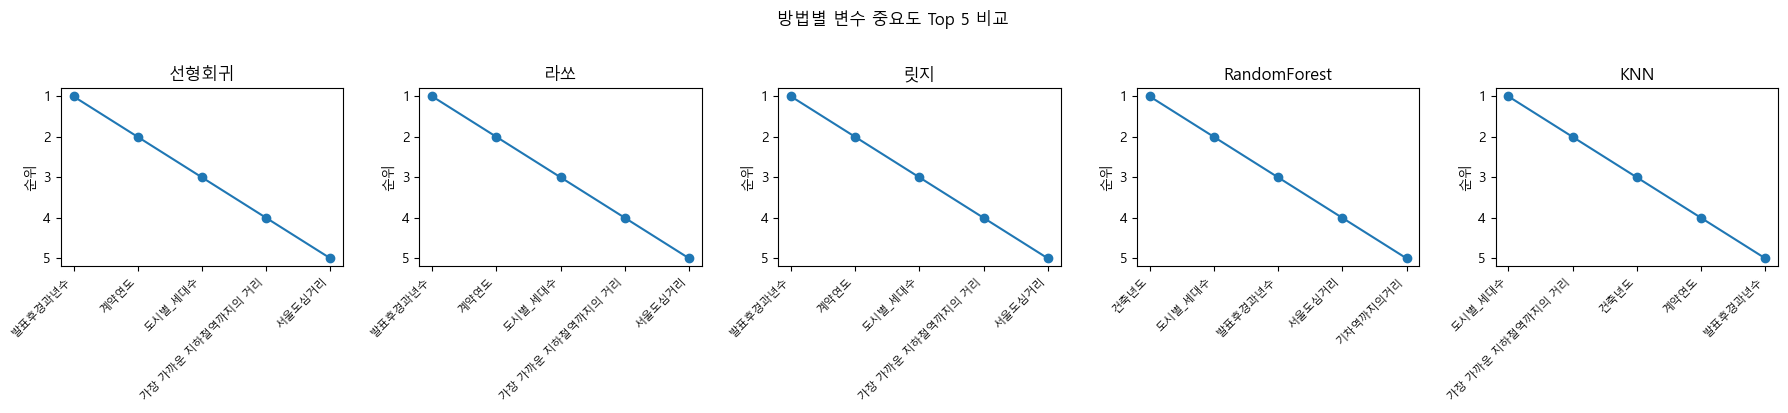

In [17]:
방법목록 = ['방법1_순위', '방법2_순위', '방법3_순위', '방법4_순위', '방법5_순위']
방법이름 = ['선형회귀', '라쏘', '릿지', 'RandomForest', 'KNN']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col, name in zip(axes, 방법목록, 방법이름):
    top = merged.sort_values(col).head(5)
    ax.plot(range(1, 6), top[col].values, 'o-')
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(top['변수'].values, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('순위')
    ax.set_title(name)
    ax.invert_yaxis()

plt.suptitle('방법별 변수 중요도 Top 5 비교', y=1.02)
plt.tight_layout()
plt.show()


## 14. 최종 Top 5 시각화

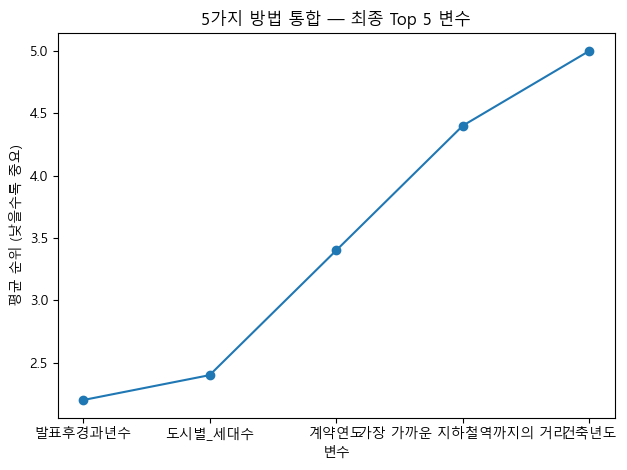

In [18]:
# 최종 Top 5 평균 순위 시각화
plt.plot(top5['변수'], top5['평균순위'], 'o-')
plt.xlabel('변수')
plt.ylabel('평균 순위 (낮을수록 중요)')
plt.title('5가지 방법 통합 — 최종 Top 5 변수')
plt.tight_layout()
plt.show()
